# **Seminar 4 - Neural Networks**
**Part I: Data preparation & analysis**
Your job in this part of the seminar is to visualize and understand the data that you are
going to use to train and evaluate your neural network. Complete the following tasks:
1. Describe the statistics behind the main parameters of the dataset. For that, make use
of the plots that you consider.
2. Perform a correlation analysis between the main features in the dataset and the performance metrics (throughput and delay).

**Part II: FNN-based performance predictor**
Now, you will design and implement a feedforward neural network (FNN) that predicts
the performance of the Wi-Fi network (throughput and latency) based on the features you
consider. The implementation of a neural network involves multiple considerations, so we
ask you to complete the following tasks:
1. Feature selection: select the features that you think will be most appropriate to
predict Wi-Fi performance.
2. Data preparation: apply the necessary data transformation techniques for your data
(e.g., normalization, encoding).
3. FNN architecture design: design your FNN and try to justify your choices (number
of layers, input/output layers, activations, loss function, optimizer, regularization, etc.)
according to the problem and data at hand.
Note: You can design a multi-output FNN that predicts both the throughput and the
delay, or define two different FNNs (with the same architecture or not) to predict the
two metrics separately.
4. Train your FNN: use the training data to train your FNN. Describe your training
approach (epochs, batches, validation) and show the training process (e.g., validation
loss per epoch).
5. Evaluate your FNN: evaluate your solution using the test data and report the results.

## **Part I: Data preparation & analysis**

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns

In [21]:
test_data = pd.read_csv("dataset_Seminar4/test_data.csv")
train_data = pd.read_csv("dataset_Seminar4/train_data.csv")
test_data

,LocationNumber,RSSI,TxLinkSpeed,RxLinkSpeed,MainAPConnect,TxThroughput,AvgPingLatency
0,16,-53.19,787.51,653.48,1,15.94,56.30
1,24,-62.79,657.90,592.37,1,17.31,49.78
2,34,-71.16,259.18,178.29,0,2.89,55.83
3,28,-63.99,467.56,375.04,1,17.01,85.71
4,6,-69.29,355.26,313.15,1,14.05,59.40
...,...,...,...,...,...,...,...
8395,12,-67.32,344.98,210.24,1,14.80,50.99
8396,8,-66.35,335.82,364.28,1,14.35,52.11
8397,9,-62.54,511.97,477.08,1,14.93,68.64
8398,10,-60.21,473.17,349.06,1,17.31,48.74


#### 1. Describe the statistics behind the main parameters of the dataset. For that, make use of the plots that you consider.

In [26]:
statistics = pd.DataFrame({
    'Feature': test_data.columns,
    'Mean': test_data.mean().values,
    'Std Dev': test_data.std().values,
    'Min': test_data.min().values,
    'Max': test_data.max().values
})

print("=" * 100)
print("FEATURE STATISTICS")
print("=" * 100)
print(statistics.to_string(index=False))

FEATURE STATISTICS
       Feature       Mean    Std Dev    Min    Max
LocationNumber  18.252500  10.396517   1.00  36.00
          RSSI -62.392752   9.574595 -78.68 -37.27
   TxLinkSpeed 490.784789 242.528150  45.64 904.92
   RxLinkSpeed 460.786707 253.640807 -24.27 907.34
 MainAPConnect   0.910833   0.285001   0.00   1.00
  TxThroughput  12.904876   4.436742   1.03  19.11
AvgPingLatency  54.679929   8.745980  39.32  96.43


#### 2. Perform a correlation analysis between the main features in the dataset and the performance metrics (throughput and delay).

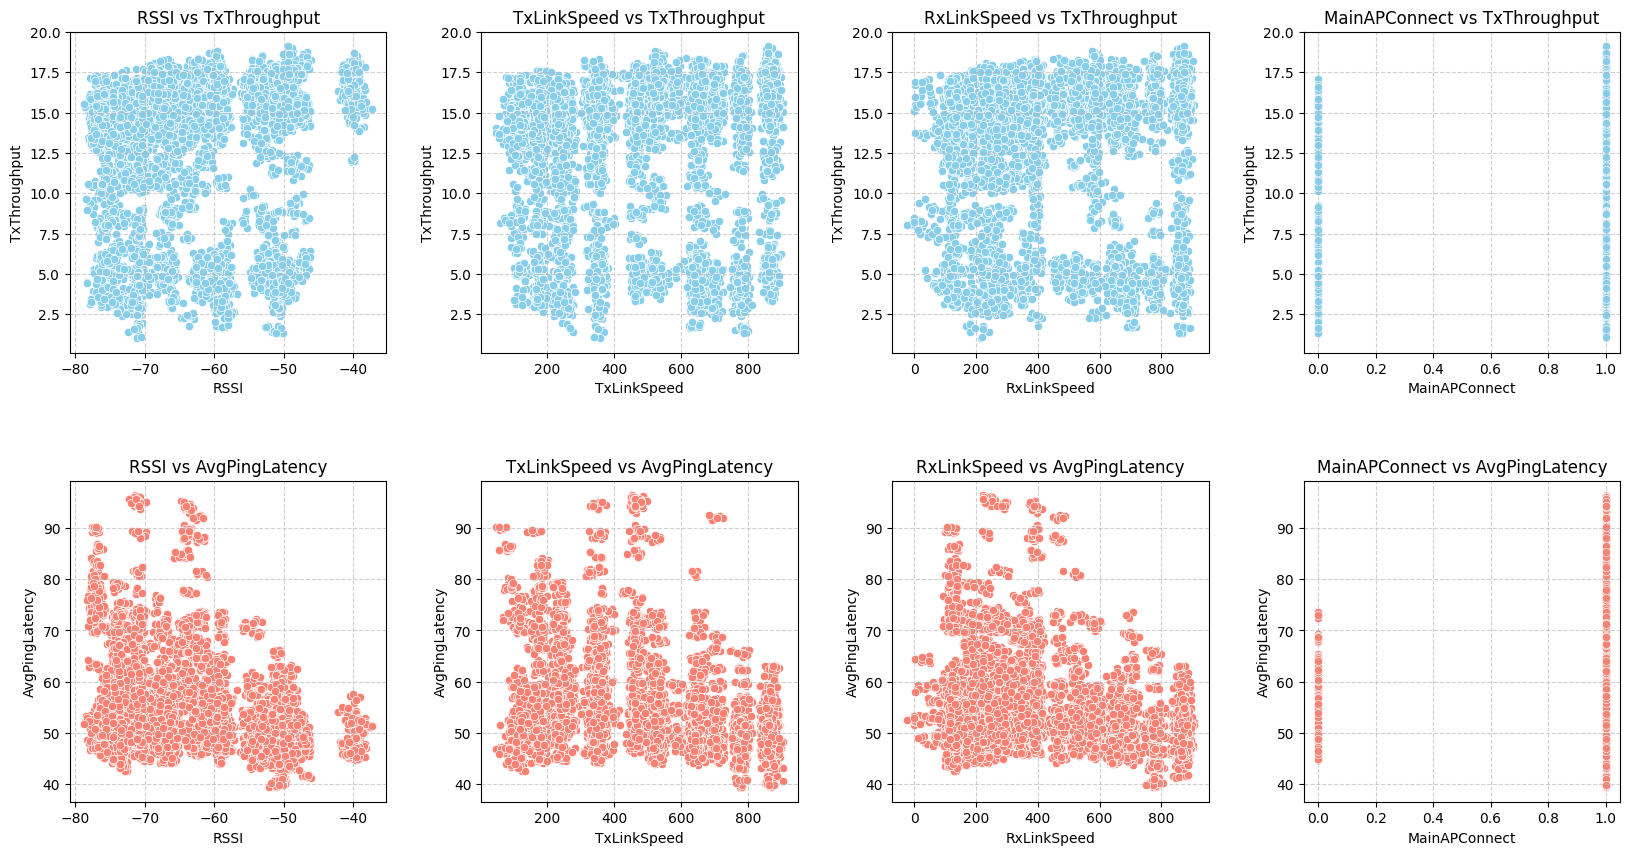

In [57]:
features = ['RSSI', 'TxLinkSpeed', 'RxLinkSpeed', 'MainAPConnect']

# Definim les variables objectiu
targets = ['TxThroughput', 'AvgPingLatency']

# Creem una figura amb dues files (una per cada "target")
fig, axes = plt.subplots(nrows=2, ncols=len(features), figsize=(20, 10))
fig.subplots_adjust(hspace=0.4, wspace=0.3)

for i, target in enumerate(targets):
    for j, feature in enumerate(features):
        sns.scatterplot(data=test_data, x=feature, y=target, ax=axes[i, j], color='skyblue' if i==0 else 'salmon')
        # test_data.plot.scatter(x=feature, y=target, c='skyblue' if i==0 else 'salmon')
        axes[i, j].set_title(f"{feature} vs {target}")
        axes[i, j].grid(True, linestyle='--', alpha=0.6)

plt.show()

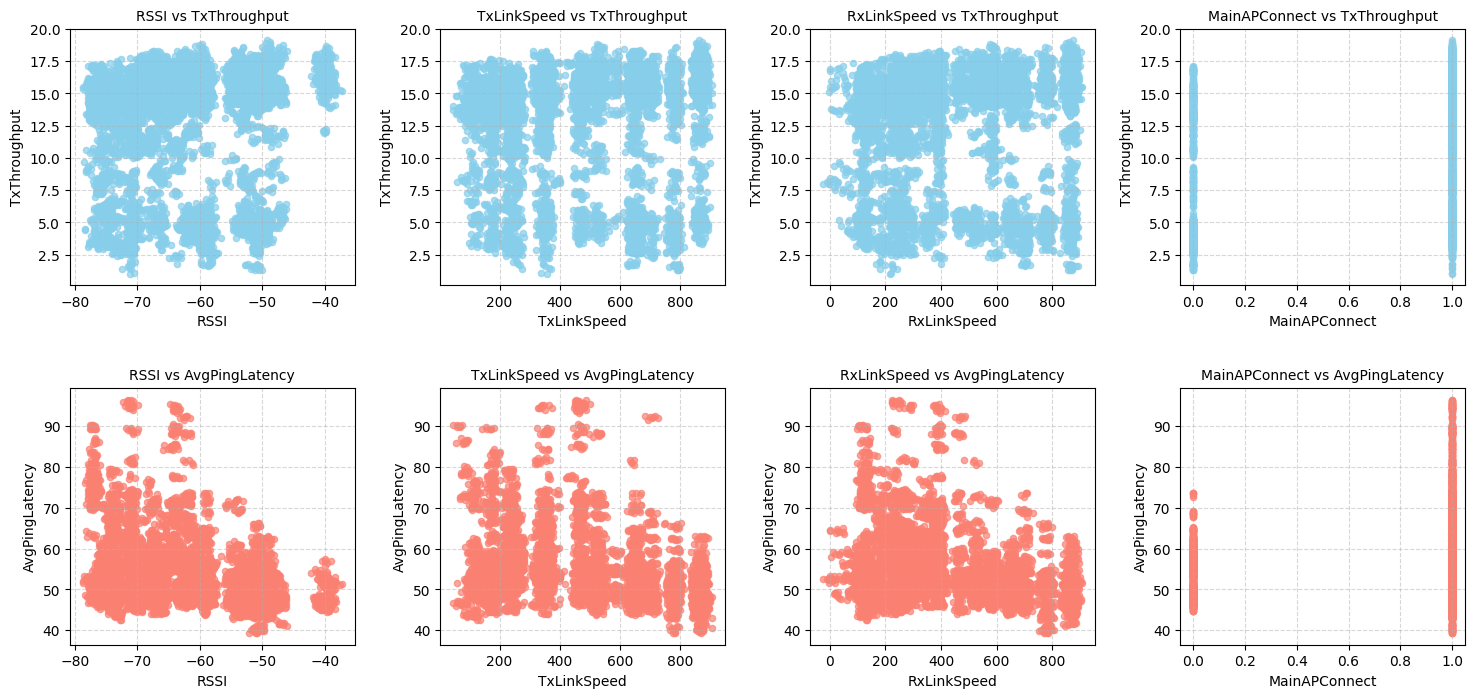

In [ ]:
features = ['RSSI', 'TxLinkSpeed', 'RxLinkSpeed', 'MainAPConnect']
targets = ['TxThroughput', 'AvgPingLatency']

fig, axes = plt.subplots(nrows=2, ncols=len(features), figsize=(18, 8))

fig.subplots_adjust(hspace=0.4, wspace=0.3)

for i, target in enumerate(targets):
    for j, feature in enumerate(features):
        ax_actual = axes[i, j]
        test_data.plot.scatter(x=feature, y=target, ax=ax_actual, c='skyblue' if i == 0 else 'salmon', alpha=0.7)
        ax_actual.grid(True, linestyle='--', alpha=0.5)
        ax_actual.set_title(f"{feature} vs {target}", fontsize=10)

plt.show()

## **Part II: FNN-based performance predictor**